In [1]:
from ml_enhance import load_hpc_result, compare
from ml_enhance import CorrelationFilter
from sklearn.base import BaseEstimator
from matplotlib.patches import Patch
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
combo_df = load_hpc_result(Path("../data/KRR_results/KRR_combo_results.pkl"), "topo+QM")

In [3]:
topo_df = load_hpc_result(Path("../data/KRR_results/KRR_topo_results.pkl"), "topo")

In [4]:
qm_df = load_hpc_result(Path("../data/KRR_results/KRR_qm_results.pkl"), "QM")

In [5]:
combo_filtered_df = load_hpc_result(Path("../data/KRR_results/KRR_combo_filtered_results.pkl"), "topo+QM_filtered")

In [6]:
r2_df = pd.concat([df[["name", "test_r2"]] for df in [topo_df, combo_df, combo_filtered_df, qm_df]])

In [7]:
print(combo_df["test_r2"].mean())
print(combo_filtered_df["test_r2"].mean())
print(topo_df["test_r2"].mean())
print(qm_df["test_r2"].mean())

0.8667893281640043
0.8664257222583575
0.8610507991863224
0.8570317308654333


C:\Users\thibo\AppData\Local\Temp\ipykernel_1768\3879470007.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


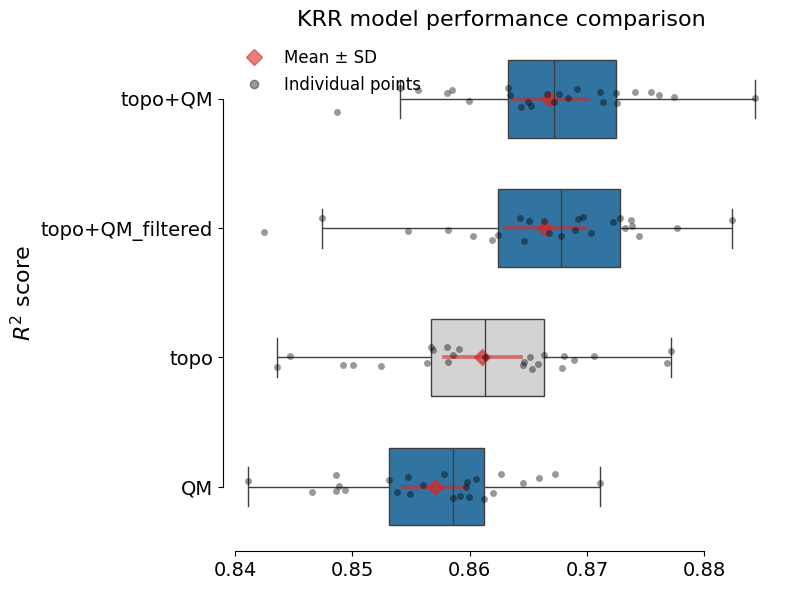

In [17]:
order = (
    r2_df.groupby("name")["test_r2"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# blue_models = ["topo+QM", "topo+QM_rfe", "topo+QM_filtered", "topo+QM_filtered_rfe"]

palette = {
    model: "tab:blue" if 'QM' in model else "lightgray"
    for model in r2_df["name"].unique()
}

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=r2_df,
    x="test_r2",
    y="name",
    order=order,
    palette=palette,
    width=0.6,
    fliersize=0
)

sns.pointplot(
    data=r2_df,
    x="test_r2",
    y="name",
    order=order,
    linestyles="None",
    color="tab:red",
    markers="D",
    alpha=0.6
)

sns.stripplot(data=r2_df, y="name", x="test_r2", color="black", alpha=0.4)

strip_handle = mlines.Line2D(
    [], [],
    color="black",
    marker="o",
    linestyle="None",
    markersize=6,
    alpha=0.4,
    label="Individual points"
)

point_handle = mlines.Line2D(
    [], [],
    color="tab:red",
    alpha=0.6,
    marker="D",
    linestyle="None",
    markersize=8,
    label="Mean ± SD"
)

legend_elements = [
    # Patch(facecolor="tab:blue", edgecolor="black", label="QM + topo"),
    # Patch(facecolor="lightgray", edgecolor="black", label="Topo-only"),
    Patch(facecolor="tab:red", edgecolor="black", label="Mean ± SD"),
    Patch(facecolor="black", edgecolor="black", label="Individual points", alpha=0.4)
]

sns.despine(trim=True, left=False)

plt.legend(handles=[point_handle, strip_handle], loc="upper left", frameon=False, fontsize=12)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("")
plt.ylabel(r"$R^2$ score", fontsize=16)
plt.title("KRR model performance comparison", fontsize=16)
# plt.xlim(0, 1)
plt.tight_layout()
# plt.savefig("HuberReg_compare.png", dpi=300)
plt.show()

In [10]:
compare(combo_df, topo_df, qm_df, n_tot=8763)

topo+QM mean r2: 0.8667893281640043 (Train: 0.9675843367784458)
topo mean r2: 0.8610507991863224 (Train: 0.9454250274352495)
QM mean r2: 0.8570317308654333 (Train: 0.9427470445785846)
Mean improvement: 0.005738528977682011
T-test p-value: 1.9812273821528947e-08 -> statistically significant
Wilcoxon p-value: 1.7881393432617188e-07 -> statistically significant


topo+QM mean MSE: 0.7088393483724018 (Train: 0.17267421914112135)
topo mean MSE: 0.7394685292365125 (Train: 0.2906573271538846)
QM mean MSE: 0.7608637801415125 (Train: 0.30493397165516234)
Mean improvement: -0.03062918086411083
T-test p-value: 2.254350395247684e-08 -> statistically significant
Wilcoxon p-value: 1.7881393432617188e-07 -> statistically significant




In [11]:
compare(combo_filtered_df, topo_df, qm_df, n_tot=8763)

topo+QM_filtered mean r2: 0.8664257222583575 (Train: 0.9638596362853572)
topo mean r2: 0.8610507991863224 (Train: 0.9454250274352495)
QM mean r2: 0.8570317308654333 (Train: 0.9427470445785846)
Mean improvement: 0.005374923072035038
T-test p-value: 2.404968351132908e-07 -> statistically significant
Wilcoxon p-value: 1.1324882507324219e-06 -> statistically significant


topo+QM_filtered mean MSE: 0.7108609977563617 (Train: 0.1924908312269966)
topo mean MSE: 0.7394685292365125 (Train: 0.2906573271538846)
QM mean MSE: 0.7608637801415125 (Train: 0.30493397165516234)
Mean improvement: -0.028607531480151004
T-test p-value: 2.2084702444580273e-07 -> statistically significant
Wilcoxon p-value: 1.1324882507324219e-06 -> statistically significant




In [12]:
from collections import Counter

all_params = [estimator.best_params_ for estimator in combo_df["estimator"]]

count = Counter(tuple(p.items()) for p in all_params)

print(count)

most_common = count.most_common(1)
best_params = dict(most_common[0][0])
best_params

Counter({(('predict__alpha', np.float64(0.008108357464023606)), ('predict__gamma', np.float64(0.0007412113876312239)), ('predict__kernel', 'rbf')): 22, (('predict__alpha', np.float64(0.0014688934368998212)), ('predict__gamma', np.float64(0.0002617390506842322)), ('predict__kernel', 'rbf')): 3})


{'predict__alpha': np.float64(0.008108357464023606),
 'predict__gamma': np.float64(0.0007412113876312239),
 'predict__kernel': 'rbf'}

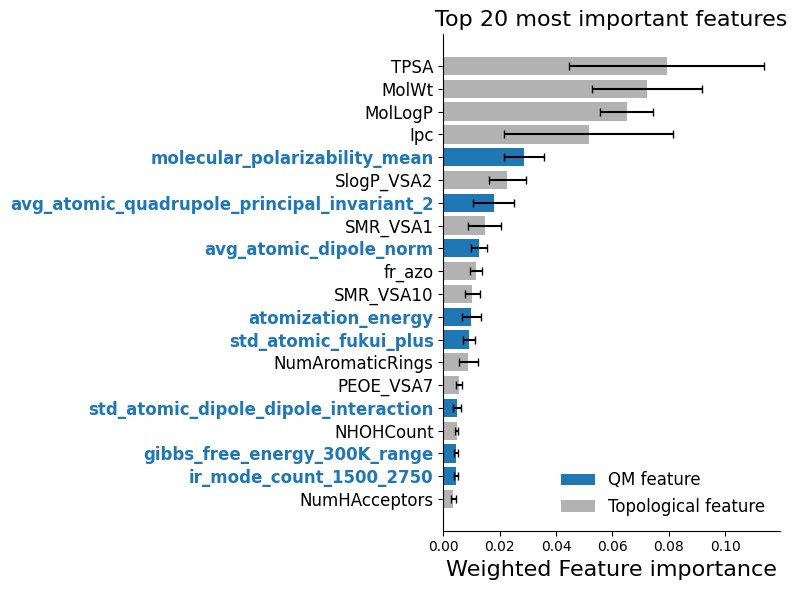

In [15]:
from ml_enhance import FeatureImportance
import pickle

file = Path(r"..\data\KRR_results\KRR_combo_filtered_PFI_results.pkl")
with file.open("rb") as f:
    data = pickle.load(f)

FI = FeatureImportance(combo_filtered_df, provided_FI=data)
fi_df = FI.get_feature_importance(20)
FI.plot(20)